In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/indo_spam.csv
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/__results__.html
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/eval.csv
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/__resultx__.html
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/__notebook__.ipynb
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/__output__.json
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/train.csv
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/test.csv
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/custom.css
/kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/__results___files/__results___8_0.png
/kaggle/input/notebooks/gevabriel/indonesian-sms-s

In [2]:
    import requests
    print(requests.get("https://huggingface.co").status_code)

200


In [ ]:
# CELL 1 - Setup Kaggle, import library, dan konfigurasi utama

import os
import re
import gc
import json
import math
import time
import copy
import random
import shutil
import subprocess
import sys
from pathlib import Path


def ensure_package(import_name, pip_name=None):
    """Install package hanya jika belum tersedia di runtime Kaggle."""
    try:
        __import__(import_name)
    except ImportError:
        package = pip_name or import_name
        print(f"Installing {package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


ensure_package("transformers", "transformers==4.38.2")
ensure_package("sklearn", "scikit-learn")
ensure_package("seaborn", "seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

try:
    from IPython.display import display
except Exception:
    display = print

os.environ["TOKENIZERS_PARALLELISM"] = "false"

CONFIG = {
    "project_title": "Deteksi Konten Penipuan (Scam) Berbahasa Indonesia",
    "model_name": "indobenchmark/indobert-base-p2",
    "seed": 42,
    "max_length": 128,
    "batch_size": 16,
    "epochs_indobert": 6,
    "epochs_hybrid": 10,
    "early_stopping_patience": 3,
    "early_stopping_min_delta": 0.0001,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "dropout": 0.30,
    "lstm_hidden_size": 256,
    "lstm_layers": 2,
    "freeze_bert_in_hybrid": False,
    "use_amp": True,
    "keep_numbers": True,
    "run_svm_baseline": True,
    "run_indobert_baseline": True,
    "run_hybrid_model": True,
    "train_size": 0.80,
    "val_size": 0.12,
    "test_size": 0.08,
}


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print("GPU:", gpu_name)
    print("CUDA version:", torch.version.cuda)
    if "P100" in gpu_name.upper():
        raise RuntimeError(
            "Error,GPU T4 x2 tidak terdeteksi"
        )
else:
    print("GPU belum aktif")


Device: cuda
GPU: Tesla T4
CUDA version: 12.8


In [ ]:
# CELL 2 - Deteksi dan load dataset dari Kaggle Input atau folder lokal


def show_available_input_files(max_files=40):
    roots = [Path("/kaggle/input"), Path("dataset"), Path(".")]
    found = []
    for root in roots:
        if root.exists():
            for file in root.rglob("*.csv"):
                found.append(file)
    print("CSV files yang terbaca:")
    for file in found[:max_files]:
        print("-", file)
    if len(found) > max_files:
        print(f"... {len(found) - max_files} file lain tidak ditampilkan")
    return found


def pick_dataset_path():
    priority_names = [
        "indo_spam.csv",
        "sms_spam_indo.csv",
        "spam.csv",
    ]
    search_roots = [Path("/kaggle/input"), Path("dataset"), Path(".")]

    for name in priority_names:
        for root in search_roots:
            if root.exists():
                matches = sorted(root.rglob(name))
                if matches:
                    return matches[0]

    split_candidates = []
    for root in search_roots:
        if root.exists():
            for name in ["train.csv", "test.csv", "eval.csv", "validation.csv", "valid.csv"]:
                split_candidates.extend(sorted(root.rglob(name)))
    if split_candidates:
        return split_candidates[0]

    raise FileNotFoundError("Dataset CSV tidak ditemukan")


available_csv = show_available_input_files()
dataset_path = pick_dataset_path()
print("\nDataset utama:", dataset_path)
raw_df = pd.read_csv(dataset_path)
print("Raw shape:", raw_df.shape)
display(raw_df.head())
print("Columns:", list(raw_df.columns))


CSV files detected:
- /kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/indo_spam.csv
- /kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/eval.csv
- /kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/train.csv
- /kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/test.csv
- scam_hybrid_indobert_bilstm/test_summary.csv
- scam_hybrid_indobert_bilstm/test_split.csv
- scam_hybrid_indobert_bilstm/train_split.csv
- scam_hybrid_indobert_bilstm/validation_split.csv
- scam_hybrid_indobert_bilstm/all_training_results.csv

Dataset utama: /kaggle/input/notebooks/gevabriel/indonesian-sms-spam-detection-using-indobert/indo_spam.csv
Raw shape: (1143, 2)


,Kategori,Pesan
0,spam,Plg Yth: Simcard anda mendptkan bonus poin plu...
1,ham,Iya ih ko sedih sih gtau kapan lg ke bandung :(
2,ham,Kalau mau bikin model/controller mending per a...
3,ham,Selamat nama1. Semoga selalu menempuh hidup ya...
4,spam,Tingkatkan nilai isi ulang Anda selanjutnya mi...


Columns: ['Kategori', 'Pesan']


In [ ]:
# CELL 3 - Standardisasi kolom teks dan label sesuai target biner scam/spam vs normal/ham

TEXT_COLUMN_CANDIDATES = ["Pesan"]
LABEL_COLUMN_CANDIDATES = ["Kategori"]

POSITIVE_LABELS = {"spam"}
NEGATIVE_LABELS = {"ham"}


def detect_column(df, candidates, column_kind):
    lower_map = {str(col).lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    raise ValueError(f"Kolom {column_kind} tidak ditemukan. Kolom tersedia: {list(df.columns)}")


def normalize_label(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text in POSITIVE_LABELS:
        return 1
    if text in NEGATIVE_LABELS:
        return 0
    try:
        numeric = int(float(text))
        if numeric in (0, 1):
            return numeric
    except Exception:
        pass
    raise ValueError(f"Label tidak dikenali: {value!r}")


text_col = detect_column(raw_df, TEXT_COLUMN_CANDIDATES, "teks")
label_col = detect_column(raw_df, LABEL_COLUMN_CANDIDATES, "label")

base_df = raw_df[[text_col, label_col]].copy()
base_df.columns = ["text", "label_raw"]
base_df["text"] = base_df["text"].astype(str)
base_df["label"] = base_df["label_raw"].apply(normalize_label)
base_df = base_df.dropna(subset=["text", "label"]).copy()
base_df["label"] = base_df["label"].astype(int)

print("Kolom teks:", text_col)
print("Kolom label:", label_col)
print("Clean base shape:", base_df.shape)
print("Distribusi label: 0=normal/ham, 1=scam/spam")
print(base_df["label"].value_counts().sort_index())
display(base_df.head())


Kolom teks: Pesan
Kolom label: Kategori
Clean base shape: (1143, 3)
Distribusi label: 0=normal/ham, 1=scam/spam
label
0    569
1    574
Name: count, dtype: int64


,text,label_raw,label
0,Plg Yth: Simcard anda mendptkan bonus poin plu...,spam,1
1,Iya ih ko sedih sih gtau kapan lg ke bandung :(,ham,0
2,Kalau mau bikin model/controller mending per a...,ham,0
3,Selamat nama1. Semoga selalu menempuh hidup ya...,ham,0
4,Tingkatkan nilai isi ulang Anda selanjutnya mi...,spam,1


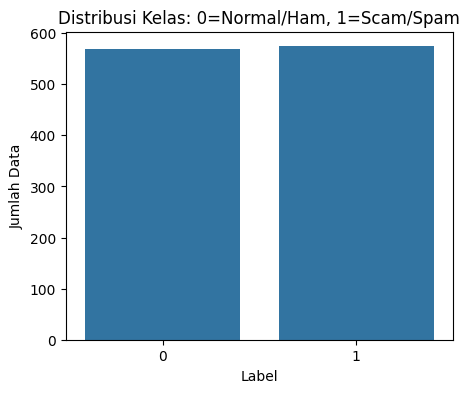

       char_len  word_len
count   1143.00   1143.00
mean     108.74     16.69
std       59.08      8.44
min       13.00      2.00
25%       58.00     10.00
50%      113.00     17.00
75%      152.00     22.00
max      434.00     63.00
Train: 913 data
{0: 454, 1: 459}
Validation: 138 data
{0: 69, 1: 69}
Test: 92 data
{0: 46, 1: 46}


In [ ]:
# CELL 4 - Exploratory Data Analysis singkat dan split data 80/12/8 sesuai proposal

plt.figure(figsize=(5, 4))
sns.countplot(data=base_df, x="label")
plt.title("Distribusi Kelas: 0=Normal/Ham, 1=Scam/Spam")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.show()

base_df["char_len"] = base_df["text"].str.len()
base_df["word_len"] = base_df["text"].str.split().str.len()
print(base_df[["char_len", "word_len"]].describe().round(2))

# train 80%, validation 12%, test 8%.
# ambil test 8%, lalu validasi 12/92 dari sisa data.
test_size = CONFIG["test_size"]
val_ratio_from_remaining = CONFIG["val_size"] / (CONFIG["train_size"] + CONFIG["val_size"])

train_val_df, test_df = train_test_split(
    base_df,
    test_size=test_size,
    stratify=base_df["label"],
    random_state=CONFIG["seed"],
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_ratio_from_remaining,
    stratify=train_val_df["label"],
    random_state=CONFIG["seed"],
)

for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name}: {len(split_df)} data")
    print(split_df["label"].value_counts().sort_index().to_dict())


In [7]:
# CELL 5 - Preprocessing teks dan normalisasi slang bahasa Indonesia

SLANG_DICT = {
    "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak", "tdk": "tidak",
    "tak": "tidak", "g": "tidak", "kagak": "tidak", "gausah": "tidak usah", "gpp": "tidak apa apa",
    "yg": "yang", "dgn": "dengan", "dng": "dengan", "dr": "dari", "dri": "dari", "ke": "ke",
    "krn": "karena", "karna": "karena", "kalo": "kalau", "kl": "kalau", "klu": "kalau",
    "utk": "untuk", "buat": "untuk", "bwt": "untuk", "dlm": "dalam", "sm": "sama", "sama2": "sama sama",
    "aja": "saja", "doang": "saja", "bgt": "banget", "bangettt": "banget", "bngt": "banget",
    "udh": "sudah", "udah": "sudah", "sdh": "sudah", "blm": "belum", "belom": "belum",
    "skrg": "sekarang", "skr": "sekarang", "td": "tadi", "tadi": "tadi", "ntr": "nanti", "ntar": "nanti",
    "lg": "lagi", "lgi": "lagi", "jg": "juga", "jgn": "jangan", "trs": "terus", "trus": "terus",
    "gw": "saya", "gue": "saya", "gua": "saya", "sy": "saya", "aq": "saya", "aku": "saya",
    "lu": "kamu", "loe": "kamu", "km": "kamu", "kmu": "kamu", "anda": "anda",
    "plg": "pelanggan", "yth": "yang terhormat", "dpt": "dapat", "dptkn": "dapatkan", "mndpt": "mendapat",
    "mndptkan": "mendapatkan", "mendptkan": "mendapatkan", "info": "informasi", "u": "untuk",
    "hub": "hubungi", "tlp": "telepon", "telp": "telepon", "hp": "handphone", "rek": "rekening",
    "tf": "transfer", "trf": "transfer", "admin": "administrasi", "rp": "rupiah", "jt": "juta", "rb": "ribu",
    "hadiahh": "hadiah", "menang": "menang", "slmt": "selamat", "selamattt": "selamat",
    "wkwk": "tertawa", "wkwkwk": "tertawa", "haha": "tertawa", "hehe": "tertawa",
    "goblok": "bodoh", "anjir": "astaga", "anjay": "astaga", "sih": "sih", "nih": "ini", "dong": "dong",
}

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
REPEATED_SPACE_PATTERN = re.compile(r"\s+")


def normalize_repeated_chars(word):
    # Batasi huruf berulang ekstrem: hadiahhhh -> hadiahh.
    return re.sub(r"(.)\1{2,}", r"\1\1", word)


def clean_text(text):
    text = str(text).lower()
    text = URL_PATTERN.sub(" link ", text)
    text = MENTION_PATTERN.sub(" user ", text)
    text = HASHTAG_PATTERN.sub(r"\1", text)

    if CONFIG["keep_numbers"]:
        text = re.sub(r"[^a-z0-9\s]", " ", text)
    else:
        text = re.sub(r"[^a-z\s]", " ", text)

    words = []
    for word in text.split():
        word = normalize_repeated_chars(word)
        word = SLANG_DICT.get(word, word)
        words.extend(word.split())

    cleaned = " ".join(words)
    cleaned = REPEATED_SPACE_PATTERN.sub(" ", cleaned).strip()
    return cleaned


sample_texts = [
    "Plg Yth: Simcard anda mendptkan bonus poin! klik www.hadiah-palsu.com",
    "Iya ih ko sedih sih gtau kapan lg ke bandung :(",
]
for sample in sample_texts:
    print("RAW  :", sample)
    print("CLEAN:", clean_text(sample))
    print()


RAW  : Plg Yth: Simcard anda mendptkan bonus poin! klik www.hadiah-palsu.com
CLEAN: pelanggan yang terhormat simcard anda mendapatkan bonus poin klik link

RAW  : Iya ih ko sedih sih gtau kapan lg ke bandung :(
CLEAN: iya ih ko sedih sih gtau kapan lagi ke bandung



In [8]:
# CELL 6 - Terapkan preprocessing ke setiap split

for split_df in [train_df, val_df, test_df]:
    split_df["clean_text"] = split_df["text"].apply(clean_text)
    empty_mask = split_df["clean_text"].str.len() == 0
    split_df.loc[empty_mask, "clean_text"] = split_df.loc[empty_mask, "text"].astype(str).str.lower()

print("Contoh hasil preprocessing:")
display(train_df[["text", "clean_text", "label"]].head(10))

print("Rata-rata panjang token setelah preprocessing:")
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    avg_len = split_df["clean_text"].str.split().str.len().mean()
    print(f"{name}: {avg_len:.2f} token")


Contoh hasil preprocessing:


,text,clean_text,label
1040,Solusi praktis khusus pemegang kartu kredit ni...,solusi praktis khusus pemegang kartu kredit ni...,1
1112,"Slmt_No. Anda Mndptkn Hadiah ""GRAND PRIZE"" Uan...",selamat no anda mndptkn hadiah grand prize uan...,1
338,Masih ingat dengan Warkop DKI ? Dapatkan NSP n...,masih ingat dengan warkop dki dapatkan nsp nya...,1
884,Ko gtu ya parah bgt masa jam kerja ngeroko. Bi...,ko gtu ya parah banget masa jam kerja ngeroko ...,0
777,Maaf kami sudah menghubungi tapi tidak tersamb...,maaf kami sudah menghubungi tapi tidak tersamb...,1
384,GRATIS PULSA hingga 250rb selama 7Hari 7Malam ...,gratis pulsa hingga 250rb selama 7hari 7malam ...,1
481,Guys numpang promosi bisi ada yg butuh.. Diju...,guys numpang promosi bisi ada yang butuh dijua...,0
1013,Aku teh cuma bawa celana jeans yg tua tp jilba...,saya teh cuma bawa celana jeans yang tua tp ji...,0
442,"Nasabah YTH, rekening BTPN Wow! Anda sudah akt...",nasabah yang terhormat rekening btpn wow anda ...,1
397,Jadi kapan kita meet upnyaa nih temaan temaan?,jadi kapan kita meet upnyaa ini temaan temaan,0


Rata-rata panjang token setelah preprocessing:
Train: 18.05 token
Validation: 18.00 token
Test: 18.72 token


In [9]:
# CELL 7 - Tokenizer IndoBERT dan Dataset PyTorch

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])


class ScamTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float),
        }


def make_loader(split_df, shuffle=False):
    dataset = ScamTextDataset(
        split_df["clean_text"].tolist(),
        split_df["label"].tolist(),
        tokenizer,
        CONFIG["max_length"],
    )
    return DataLoader(
        dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df, shuffle=False)
test_loader = make_loader(test_df, shuffle=False)

batch = next(iter(train_loader))
print("Batch input_ids:", batch["input_ids"].shape)
print("Batch attention_mask:", batch["attention_mask"].shape)
print("Batch labels:", batch["labels"].shape)


Batch input_ids: torch.Size([16, 128])
Batch attention_mask: torch.Size([16, 128])
Batch labels: torch.Size([16])


In [10]:
# CELL 8 - Helper evaluasi, threshold tuning, dan visualisasi Confusion Matrix

RESULTS = []


def logits_to_positive_probs(logits):
    if logits.ndim == 2 and logits.shape[-1] == 2:
        return torch.softmax(logits, dim=1)[:, 1]
    return torch.sigmoid(logits.view(-1))


def evaluate_binary(y_true, y_prob=None, y_pred=None, threshold=0.5):
    if y_pred is None:
        y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "threshold": threshold,
    }
    if y_prob is not None and len(np.unique(y_true)) == 2:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
        except Exception:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan
    return metrics


def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.20, 0.81, 0.01)
    best_threshold = 0.50
    best_f1 = -1
    for threshold in thresholds:
        score = f1_score(y_true, (np.asarray(y_prob) >= threshold).astype(int), zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = float(threshold)
    return best_threshold, best_f1


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal/Ham", "Scam/Spam"],
        yticklabels=["Normal/Ham", "Scam/Spam"],
    )
    plt.title(title)
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.show()
    return cm


def append_result(model_name, split_name, metrics):
    row = {"model": model_name, "split": split_name}
    row.update(metrics)
    RESULTS.append(row)
    return row


Training baseline SVM TF-IDF ...
SVM selesai dalam 0.07 detik
Validation: {'accuracy': 0.9637681159420289, 'precision': 0.9324324324324325, 'recall': 1.0, 'f1': 0.965034965034965, 'threshold': 0.5, 'roc_auc': nan}
Test: {'accuracy': 0.9565217391304348, 'precision': 0.9375, 'recall': 0.9782608695652174, 'f1': 0.9574468085106383, 'threshold': 0.5, 'roc_auc': nan}

Classification Report - SVM Test
              precision    recall  f1-score   support

  Normal/Ham       0.98      0.93      0.96        46
   Scam/Spam       0.94      0.98      0.96        46

    accuracy                           0.96        92
   macro avg       0.96      0.96      0.96        92
weighted avg       0.96      0.96      0.96        92



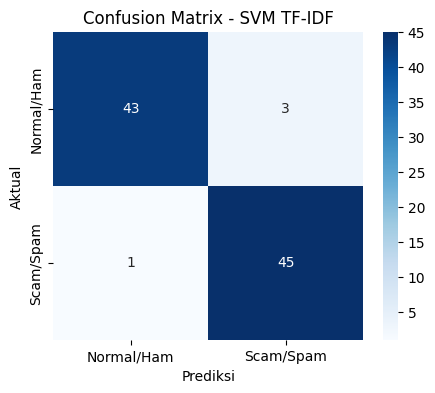

In [11]:
# CELL 9 - Baseline Machine Learning: TF-IDF + Linear SVM

if CONFIG["run_svm_baseline"]:
    print("Training baseline SVM TF-IDF ...")
    start = time.time()

    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
    )
    X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
    X_val_tfidf = tfidf.transform(val_df["clean_text"])
    X_test_tfidf = tfidf.transform(test_df["clean_text"])

    svm_model = LinearSVC(class_weight="balanced", random_state=CONFIG["seed"])
    svm_model.fit(X_train_tfidf, train_df["label"])

    svm_val_pred = svm_model.predict(X_val_tfidf)
    svm_test_pred = svm_model.predict(X_test_tfidf)

    svm_val_metrics = evaluate_binary(val_df["label"], y_pred=svm_val_pred)
    svm_test_metrics = evaluate_binary(test_df["label"], y_pred=svm_test_pred)

    append_result("SVM TF-IDF", "validation", svm_val_metrics)
    append_result("SVM TF-IDF", "test", svm_test_metrics)

    print(f"SVM selesai dalam {time.time() - start:.2f} detik")
    print("Validation:", svm_val_metrics)
    print("Test:", svm_test_metrics)
    print("\nClassification Report - SVM Test")
    print(classification_report(test_df["label"], svm_test_pred, target_names=["Normal/Ham", "Scam/Spam"], zero_division=0))
    plot_confusion(test_df["label"], svm_test_pred, "Confusion Matrix - SVM TF-IDF")
else:
    print("SVM baseline dilewati.")


In [12]:
# CELL 10 - Definisi model IndoBERT baseline dan Hybrid IndoBERT + Bi-LSTM

class IndoBertClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, 2)
        self.loss_type = "ce"

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_embedding))
        return logits


class AttentionPooling(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(input_size, input_size // 2),
            nn.Tanh(),
            nn.Linear(input_size // 2, 1, bias=False),
        )

    def forward(self, sequence_output, attention_mask):
        scores = self.score(sequence_output).squeeze(-1)
        scores = scores.masked_fill(attention_mask == 0, -1e4)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(sequence_output * weights.unsqueeze(-1), dim=1)
        return pooled


class HybridIndoBertBiLSTM(nn.Module):
    def __init__(self, model_name, lstm_hidden_size=256, lstm_layers=2, dropout=0.3, freeze_bert=False):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        bert_hidden_size = self.bert.config.hidden_size

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=bert_hidden_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        bilstm_output_size = lstm_hidden_size * 2
        self.attention_pooling = AttentionPooling(bilstm_output_size)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(bilstm_output_size, 1)
        self.loss_type = "bce"

    def forward(self, input_ids, attention_mask):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_outputs.last_hidden_state
        lstm_output, _ = self.lstm(sequence_output)
        pooled = self.attention_pooling(lstm_output, attention_mask)
        logits = self.classifier(self.dropout(pooled)).squeeze(-1)
        return logits


print("Model classes siap.")


Model classes siap.


In [13]:
# CELL 11 - Training loop PyTorch dengan validation F1 checkpointing


def compute_class_weights(labels):
    labels = np.asarray(labels).astype(int)
    neg = max((labels == 0).sum(), 1)
    pos = max((labels == 1).sum(), 1)
    ce_weights = torch.tensor([1.0, neg / pos], dtype=torch.float, device=device)
    pos_weight = torch.tensor([neg / pos], dtype=torch.float, device=device)
    return ce_weights, pos_weight


def build_loss_fn(loss_type, labels):
    ce_weights, pos_weight = compute_class_weights(labels)
    if loss_type == "ce":
        return nn.CrossEntropyLoss(weight=ce_weights)
    if loss_type == "bce":
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    raise ValueError(f"Unknown loss_type: {loss_type}")


def calculate_loss(logits, labels, loss_fn, loss_type):
    if loss_type == "ce":
        return loss_fn(logits, labels.long())
    return loss_fn(logits.view(-1), labels.float())


def predict_torch_model(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = logits_to_positive_probs(logits)
            all_probs.extend(probs.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())
    return np.asarray(all_labels), np.asarray(all_probs)


def train_torch_model(model, model_name, epochs):
    model = model.to(device)
    loss_fn = build_loss_fn(model.loss_type, train_df["label"].values)
    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )

    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * CONFIG["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"] and device.type == "cuda")
    best_state = None
    best_record = None
    best_f1 = -1.0
    epochs_without_improvement = 0

    print(f"\nTraining {model_name} ...")
    start_all = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        start_epoch = time.time()

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):
                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = calculate_loss(logits, labels, loss_fn, model.loss_type)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()

        avg_loss = running_loss / max(len(train_loader), 1)
        val_labels, val_probs = predict_torch_model(model, val_loader)
        best_threshold, _ = find_best_threshold(val_labels, val_probs)
        val_metrics = evaluate_binary(val_labels, y_prob=val_probs, threshold=best_threshold)
        append_result(model_name, f"validation_epoch_{epoch}", val_metrics)

        print(
            f"Epoch {epoch}/{epochs} | loss={avg_loss:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
            f"thr={best_threshold:.2f} | time={time.time() - start_epoch:.1f}s"
        )

        improved = val_metrics["f1"] > (best_f1 + CONFIG.get("early_stopping_min_delta", 0.0))
        if improved:
            best_f1 = val_metrics["f1"]
            epochs_without_improvement = 0
            best_record = {
                "epoch": epoch,
                "threshold": best_threshold,
                "metrics": val_metrics,
            }
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        patience = CONFIG.get("early_stopping_patience")
        if patience and epochs_without_improvement >= patience:
            print(
                f"Early stopping aktif: tidak ada peningkatan val_f1 selama "
                f"{epochs_without_improvement} epoch. Best epoch={best_record['epoch']} | "
                f"best_val_f1={best_f1:.4f}"
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"{model_name} selesai dalam {(time.time() - start_all) / 60:.2f} menit")
    print("Best validation:", best_record)
    return model, best_record


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Training IndoBERT Classifier ...


/tmp/ipykernel_293/2209633991.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"] and device.type == "cuda")
/tmp/ipykernel_293/2209633991.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):


Epoch 1/6 | loss=0.2275 | val_f1=0.9650 | val_acc=0.9638 | thr=0.32 | time=9.2s


/tmp/ipykernel_293/2209633991.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):


...

Epoch 4/6 | loss=0.0012 | val_f1=0.9718 | val_acc=0.9710 | thr=0.20 | time=8.7s


/tmp/ipykernel_293/2209633991.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):


Epoch 5/6 | loss=0.0013 | val_f1=0.9718 | val_acc=0.9710 | thr=0.20 | time=8.8s


/tmp/ipykernel_293/2209633991.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):


Epoch 6/6 | loss=0.0001 | val_f1=0.9718 | val_acc=0.9710 | thr=0.20 | time=8.9s
Early stopping aktif: tidak ada peningkatan val_f1 selama 3 epoch. Best epoch=3 | best_val_f1=0.9787
IndoBERT Classifier selesai dalam 0.91 menit
Best validation: {'epoch': 3, 'threshold': 0.7500000000000004, 'metrics': {'accuracy': 0.9782608695652174, 'precision': 0.9583333333333334, 'recall': 1.0, 'f1': 0.9787234042553191, 'threshold': 0.7500000000000004, 'roc_auc': np.float64(0.9983196807393404)}}

Classification Report - IndoBERT Test
              precision    recall  f1-score   support

  Normal/Ham       1.00      0.98      0.99        46
   Scam/Spam       0.98      1.00      0.99        46

    accuracy                           0.99        92
   macro avg       0.99      0.99      0.99        92
weighted avg       0.99      0.99      0.99        92



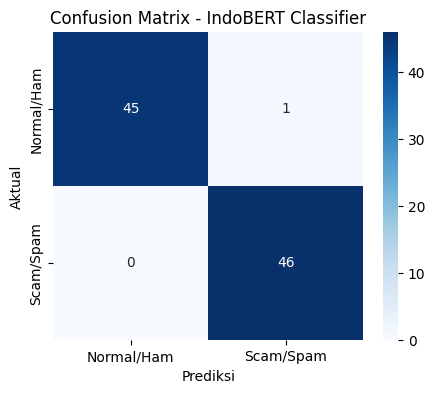

In [14]:
# CELL 12 - Training baseline IndoBERT classifier

indobert_model = None
indobert_best = None
indobert_test_probs = None
indobert_test_pred = None

if CONFIG["run_indobert_baseline"]:
    indobert_model = IndoBertClassifier(CONFIG["model_name"], dropout=CONFIG["dropout"])
    indobert_model, indobert_best = train_torch_model(
        indobert_model,
        model_name="IndoBERT Classifier",
        epochs=CONFIG["epochs_indobert"],
    )

    test_labels, indobert_test_probs = predict_torch_model(indobert_model, test_loader)
    indobert_threshold = indobert_best["threshold"]
    indobert_test_pred = (indobert_test_probs >= indobert_threshold).astype(int)
    indobert_test_metrics = evaluate_binary(test_labels, y_prob=indobert_test_probs, threshold=indobert_threshold)
    append_result("IndoBERT Classifier", "test", indobert_test_metrics)

    print("\nClassification Report - IndoBERT Test")
    print(classification_report(test_labels, indobert_test_pred, target_names=["Normal/Ham", "Scam/Spam"], zero_division=0))
    plot_confusion(test_labels, indobert_test_pred, "Confusion Matrix - IndoBERT Classifier")

    # Bebaskan memori sebelum training hybrid.
    indobert_model_cpu_state = {k: v.detach().cpu().clone() for k, v in indobert_model.state_dict().items()}
    del indobert_model
    gc.collect()
    torch.cuda.empty_cache()
else:
    print("Baseline IndoBERT dilewati.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Training Hybrid IndoBERT+BiLSTM ...


/tmp/ipykernel_293/2209633991.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"] and device.type == "cuda")
/tmp/ipykernel_293/2209633991.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):


Epoch 1/10 | loss=0.4654 | val_f1=0.9583 | val_acc=0.9565 | thr=0.20 | time=10.1s


/tmp/ipykernel_293/2209633991.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):


...

Epoch 3/10 | loss=0.0917 | val_f1=0.9787 | val_acc=0.9783 | thr=0.28 | time=9.9s


/tmp/ipykernel_293/2209633991.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):


Epoch 4/10 | loss=0.0514 | val_f1=0.9718 | val_acc=0.9710 | thr=0.20 | time=9.8s


/tmp/ipykernel_293/2209633991.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"] and device.type == "cuda"):


Epoch 5/10 | loss=0.0389 | val_f1=0.9718 | val_acc=0.9710 | thr=0.20 | time=9.7s
Early stopping aktif: tidak ada peningkatan val_f1 selama 3 epoch. Best epoch=2 | best_val_f1=0.9787
Hybrid IndoBERT+BiLSTM selesai dalam 0.85 menit
Best validation: {'epoch': 2, 'threshold': 0.6800000000000004, 'metrics': {'accuracy': 0.9782608695652174, 'precision': 0.9583333333333334, 'recall': 1.0, 'f1': 0.9787234042553191, 'threshold': 0.6800000000000004, 'roc_auc': np.float64(0.9991598403696702)}}

Classification Report - Hybrid Test
              precision    recall  f1-score   support

  Normal/Ham       0.98      0.98      0.98        46
   Scam/Spam       0.98      0.98      0.98        46

    accuracy                           0.98        92
   macro avg       0.98      0.98      0.98        92
weighted avg       0.98      0.98      0.98        92



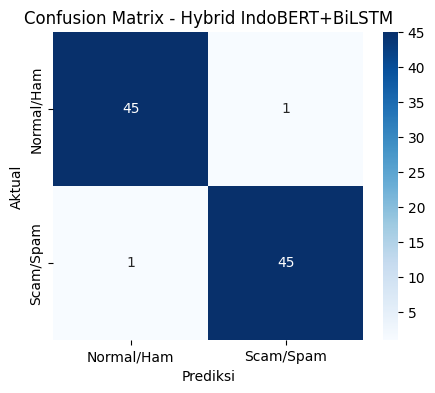

In [15]:
# CELL 13 - Training model utama: Hybrid IndoBERT + Bi-LSTM

hybrid_model = None
hybrid_best = None
hybrid_test_probs = None
hybrid_test_pred = None

if CONFIG["run_hybrid_model"]:
    hybrid_model = HybridIndoBertBiLSTM(
        model_name=CONFIG["model_name"],
        lstm_hidden_size=CONFIG["lstm_hidden_size"],
        lstm_layers=CONFIG["lstm_layers"],
        dropout=CONFIG["dropout"],
        freeze_bert=CONFIG["freeze_bert_in_hybrid"],
    )
    hybrid_model, hybrid_best = train_torch_model(
        hybrid_model,
        model_name="Hybrid IndoBERT+BiLSTM",
        epochs=CONFIG["epochs_hybrid"],
    )

    test_labels, hybrid_test_probs = predict_torch_model(hybrid_model, test_loader)
    hybrid_threshold = hybrid_best["threshold"]
    hybrid_test_pred = (hybrid_test_probs >= hybrid_threshold).astype(int)
    hybrid_test_metrics = evaluate_binary(test_labels, y_prob=hybrid_test_probs, threshold=hybrid_threshold)
    append_result("Hybrid IndoBERT+BiLSTM", "test", hybrid_test_metrics)

    print("\nClassification Report - Hybrid Test")
    print(classification_report(test_labels, hybrid_test_pred, target_names=["Normal/Ham", "Scam/Spam"], zero_division=0))
    hybrid_cm = plot_confusion(test_labels, hybrid_test_pred, "Confusion Matrix - Hybrid IndoBERT+BiLSTM")
else:
    print("Model hybrid dilewati.")


Ringkasan hasil TEST:


,model,split,accuracy,precision,recall,f1,roc_auc,threshold
8,IndoBERT Classifier,test,0.9891,0.9787,1.0000,0.9892,1.0000,0.7500
14,Hybrid IndoBERT+BiLSTM,test,0.9783,0.9783,0.9783,0.9783,0.9939,0.6800
1,SVM TF-IDF,test,0.9565,0.9375,0.9783,0.9574,nan,0.5000


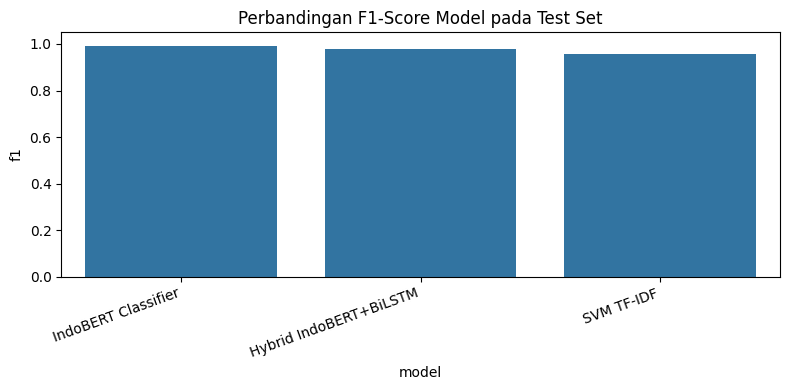

Catatan interpretasi:
- Precision tinggi berarti prediksi scam jarang salah menuduh pesan normal.
- Recall tinggi berarti pesan scam lebih sedikit yang lolos sebagai normal.
- F1 menjadi metrik utama karena menyeimbangkan precision dan recall.


In [16]:
# CELL 14 - Ringkasan hasil akhir semua model

results_df = pd.DataFrame(RESULTS)
summary_df = results_df[results_df["split"].eq("test")].copy()
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "threshold"]
summary_df = summary_df[["model", "split"] + metric_cols].sort_values("f1", ascending=False)

print("Ringkasan hasil TEST:")
display(summary_df.style.format({col: "{:.4f}" for col in metric_cols}))

plt.figure(figsize=(8, 4))
sns.barplot(data=summary_df, x="model", y="f1")
plt.title("Perbandingan F1-Score Model pada Test Set")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("Catatan interpretasi:")
print("- Precision tinggi berarti prediksi scam jarang salah menuduh pesan normal.")
print("- Recall tinggi berarti pesan scam lebih sedikit yang lolos sebagai normal.")
print("- F1 menjadi metrik utama karena menyeimbangkan precision dan recall.")


In [17]:
# CELL 15 - Simpan artifact model, tokenizer, preprocessing config, dan hasil evaluasi ke /kaggle/working

OUTPUT_DIR = Path("/kaggle/working/scam_hybrid_indobert_bilstm") if Path("/kaggle/working").exists() else Path("outputs/scam_hybrid_indobert_bilstm")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Simpan tokenizer agar inference konsisten.
tokenizer.save_pretrained(OUTPUT_DIR / "tokenizer")

# Simpan hasil evaluasi.
results_df.to_csv(OUTPUT_DIR / "all_training_results.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "test_summary.csv", index=False)

# Simpan split data untuk bukti eksperimen.
train_df[["text", "clean_text", "label"]].to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df[["text", "clean_text", "label"]].to_csv(OUTPUT_DIR / "validation_split.csv", index=False)
test_df[["text", "clean_text", "label"]].to_csv(OUTPUT_DIR / "test_split.csv", index=False)

# Simpan konfigurasi preprocessing dan label.
preprocessing_config = {
    "label_mapping": {"normal_ham": 0, "scam_spam": 1},
    "slang_dict": SLANG_DICT,
    "config": CONFIG,
    "text_column_source": text_col,
    "label_column_source": label_col,
    "dataset_path": str(dataset_path),
}
with open(OUTPUT_DIR / "preprocessing_config.json", "w", encoding="utf-8") as f:
    json.dump(preprocessing_config, f, ensure_ascii=False, indent=2)

# Simpan model utama Hybrid IndoBERT+BiLSTM.
if hybrid_model is not None:
    hybrid_checkpoint = {
        "model_name": CONFIG["model_name"],
        "architecture": "HybridIndoBertBiLSTM",
        "state_dict": {k: v.detach().cpu() for k, v in hybrid_model.state_dict().items()},
        "best_validation": hybrid_best,
        "threshold": hybrid_best["threshold"],
        "config": CONFIG,
        "label_mapping": {"normal_ham": 0, "scam_spam": 1},
    }
    torch.save(hybrid_checkpoint, OUTPUT_DIR / "hybrid_indobert_bilstm_scam_final.pth")

# Simpan baseline IndoBERT jika tadi dijalankan.
if "indobert_model_cpu_state" in globals():
    indobert_checkpoint = {
        "model_name": CONFIG["model_name"],
        "architecture": "IndoBertClassifier",
        "state_dict": indobert_model_cpu_state,
        "best_validation": indobert_best,
        "threshold": indobert_best["threshold"],
        "config": CONFIG,
        "label_mapping": {"normal_ham": 0, "scam_spam": 1},
    }
    torch.save(indobert_checkpoint, OUTPUT_DIR / "indobert_classifier_scam_baseline.pth")

# Zip semua artifact agar mudah di-download dari Kaggle Output.
zip_path = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
print("Artifact folder:", OUTPUT_DIR)
print("ZIP artifact:", zip_path)
print("Files:")
for file in sorted(OUTPUT_DIR.rglob("*")):
    print("-", file.relative_to(OUTPUT_DIR))


Artifact folder: /kaggle/working/scam_hybrid_indobert_bilstm
ZIP artifact: /kaggle/working/scam_hybrid_indobert_bilstm.zip
Files:
- all_training_results.csv
- hybrid_indobert_bilstm_scam_final.pth
- indobert_classifier_scam_baseline.pth
- preprocessing_config.json
- test_split.csv
- test_summary.csv
- tokenizer
- tokenizer/tokenizer.json
- tokenizer/tokenizer_config.json
- train_split.csv
- validation_split.csv


In [18]:
# CELL 16 - Fungsi prediksi teks baru menggunakan model Hybrid


def predict_scam(text, model=None, threshold=None):
    if model is None:
        model = hybrid_model
    if model is None:
        raise ValueError("Hybrid model belum tersedia. Jalankan CELL 13 terlebih dahulu.")
    if threshold is None:
        threshold = hybrid_best["threshold"] if hybrid_best else 0.5

    model.eval()
    cleaned = clean_text(text)
    encoding = tokenizer(
        cleaned,
        truncation=True,
        padding="max_length",
        max_length=CONFIG["max_length"],
        return_tensors="pt",
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        prob = logits_to_positive_probs(logits).item()

    label = "SCAM/SPAM" if prob >= threshold else "NORMAL/HAM"
    return {
        "raw_text": text,
        "clean_text": cleaned,
        "prob_scam": prob,
        "threshold": threshold,
        "prediction": label,
    }


example_texts = [
    "Selamat Anda memenangkan hadiah 100 juta. Transfer biaya admin ke rekening 1234 sekarang.",
    "Besok kita kumpul jam 10 di kampus untuk diskusi tugas akhir.",
]

for text in example_texts:
    result = predict_scam(text)
    print(json.dumps(result, ensure_ascii=False, indent=2))


{
  "raw_text": "Selamat Anda memenangkan hadiah 100 juta. Transfer biaya admin ke rekening 1234 sekarang.",
  "clean_text": "selamat anda memenangkan hadiah 100 juta transfer biaya administrasi ke rekening 1234 sekarang",
  "prob_scam": 0.9559469819068909,
  "threshold": 0.6800000000000004,
  "prediction": "SCAM/SPAM"
}
{
  "raw_text": "Besok kita kumpul jam 10 di kampus untuk diskusi tugas akhir.",
  "clean_text": "besok kita kumpul jam 10 di kampus untuk diskusi tugas akhir",
  "prob_scam": 0.021125299856066704,
  "threshold": 0.6800000000000004,
  "prediction": "NORMAL/HAM"
}
